# Gaussian Process Classification - `Iris` Dataset

We are going to apply logistic regression to the classic `iris` dataset which has measurements from flowers from three closely related species: `setosa`, `virginica`, and `versicolor`. These measurements are the `petal length`, `petal width`, `sepal length`, and `sepal width`. In case you are wondering, sepals are modified leaves whose function is generally related to protecting the flowers in a bud.

We are going to begin with a simple case. Let's assume we only have two classes, `setosa`, and `versicolor`, and just one independent variable or feature, `sepal_length`. We want to predict the probability of a flower being `setosa` given its `sepal length`.

**Task 1a**: As is usually done, encode the `setosa` and `versicolor` categories with the numbers $0$ and $1$ and scale `sepal_length` by using `pandas`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

# ==========================================================
# 1. Load IRIS dataset and filter two classes
# ==========================================================
iris = load_iris()
X = iris.data[:, :1]  # ONLY sepal_length
y = iris.target

# Keep only setosa (0) and versicolor (1)
mask = (y == 0) | (y == 1)
X = X[mask]
y = y[mask]

# Normalize sepal length (optional but helpful)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



**Task 1b**: Combine three kernels: the _exponential quadratic kernel_, a _linear kernel_, and a _white noise kernel_. Fit a Gaussian Process with this kernel and predict the CDF probabilities belonging to the class `setosa` for 300 equidistant points in the value range of the predictor variable.

- The _linear kernel_ will have the effect of making the tails got to 0 or 1 at the boundaries of the data.
- _White noise kernel_ is used as trick to stabilize the computation of the covariance matrix: Kernels of Gaussian processes are restricted to guarantee the resulting covariance matrix is positive definite. Nevertheless, numerical errors can lead to violating this condition. One manifestation is that we get NaNs when computing posterior predictive samples of the fitted function. One way to mitigate this error is to stabilize the computation by adding some noise.


In [2]:
# ==========================================================
# 2. Build Gaussian Process Classifier (PROBIT link)
# ==========================================================
kernel = (
    1.0 * RBF(length_scale=1.0)      # smooth nonlinear component
    + 1.0 * DotProduct()             # linear tails → goes to 0/1 far away
    + WhiteKernel(noise_level=1e-3)  # numerical stabilizer
)

gp_probit = GaussianProcessClassifier(
    kernel=kernel,
    optimizer="fmin_l_bfgs_b",
    max_iter_predict=200,
    warm_start=True
)

gp_probit.fit(X_scaled, y)

print("GP kernel after fitting:")
print(gp_probit.kernel_)

# ==========================================================
# 3. Prepare grid for plotting predictions
# ==========================================================
x_plot = np.linspace(X.min()-0.5, X.max()+0.5, 300).reshape(-1,1)
x_plot_scaled = scaler.transform(x_plot)

# GP predicted CDF probabilities (probit)
gp_probs = gp_probit.predict_proba(x_plot_scaled)[:, 1]

GP kernel after fitting:
0.165**2 * RBF(length_scale=7.17) + 3.11**2 * DotProduct(sigma_0=0.0119) + WhiteKernel(noise_level=0.000995)


**Task 1c**: Generate a figure showing the probability of being `versicolor` $\theta$ versus the `sepal length`.

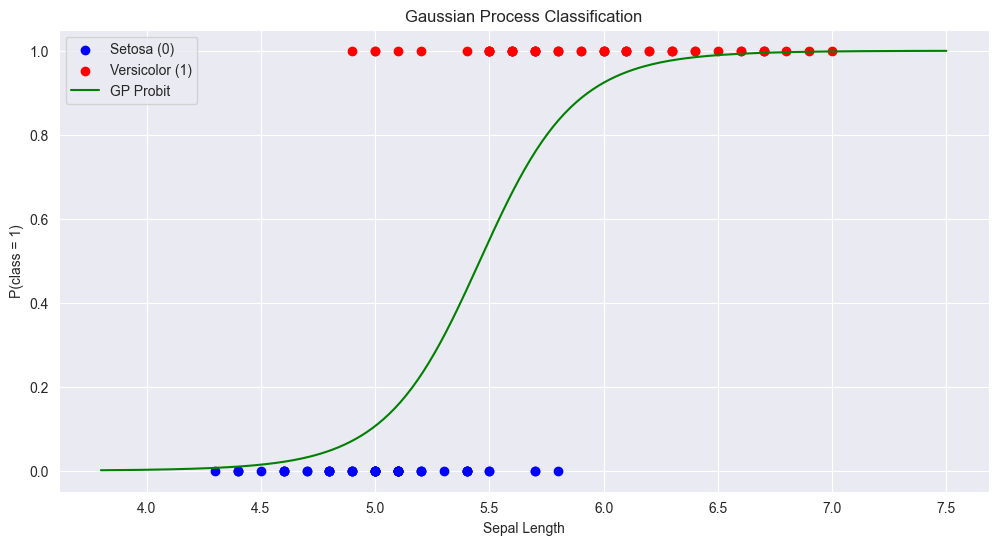

In [3]:
# ==========================================================
# 4. Plot everything
# ==========================================================
plt.figure(figsize=(12, 6))

# Training data
plt.scatter(X[y==0], y[y==0], color='blue', label="Setosa (0)")
plt.scatter(X[y==1], y[y==1], color='red', label="Versicolor (1)")

# GP curve
plt.plot(x_plot, gp_probs, 'g-', label="GP Probit")


plt.xlabel("Sepal Length")
plt.ylabel("P(class = 1)")
plt.title("Gaussian Process Classification")
plt.legend()
plt.grid(True)
plt.show()


**Task 1d**: Split the data into a training and test data set. The test dataset should contain 30\% of the entire dataset. What is the accuracy of the Probit Gaussian Process?

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=0
)

gp_probit = GaussianProcessClassifier(
    kernel=kernel,
    optimizer="fmin_l_bfgs_b",
    max_iter_predict=200,
    warm_start=True
)

gp_probit.fit(X_train, y_train)

# Accuracy
y_train_pred = gp_probit.predict(X_train)
y_test_pred = gp_probit.predict(X_test)

acc_train = accuracy_score(y_train, y_train_pred)
acc_test = accuracy_score(y_test, y_test_pred)

print("Gaussian Process Classifier:")
print(f"  Train accuracy = {acc_train:.3f}")
print(f"  Test accuracy  = {acc_test:.3f}")


Gaussian Process Classifier:
  Train accuracy = 0.871
  Test accuracy  = 0.933


**Task 1e**: Use `sepal length` and `sepal width` as predictor variables to predict all three classes `versicolor`, `viriginica`, `setosa`. Scale the two prodictor variables, and compute the training accuracy of the predicted three classes.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# -------------------------------------------------
# Load full iris dataset (3 classes)
# -------------------------------------------------
data = load_iris()
X = data.data[:, :2]
y = data.target
class_names = data.target_names

# Standardize inputs
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------------------------------
# Build GP kernel
# -------------------------------------------------
kernel = 1.0 * RBF(length_scale=1.0) + \
         1.0 * DotProduct() + \
         WhiteKernel(noise_level=0.1)

gp = GaussianProcessClassifier(kernel=kernel,
                               multi_class="one_vs_rest",
                               n_jobs=-1)

# -------------------------------------------------
# Fit GP classifier
# -------------------------------------------------
gp.fit(X, y)
print("Optimized Kernel:", gp.kernel_)

# -------------------------------------------------
# Evaluate accuracy
# -------------------------------------------------
y_pred = gp.predict(X)
acc = accuracy_score(y, y_pred)
cm = confusion_matrix(y, y_pred)

print("\nAccuracy:", acc)
print("\nConfusion Matrix:\n", cm)



/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__sigma_0 is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/marbetschar/Development/marbetschar/notes/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may fi

Optimized Kernel: CompoundKernel(6.62, 1.06, 7.14, -11.5, -11.5, 2.05, 0.34, -0.135, 1.17, -11.5, -2.47, 4.58, 0.852, -0.24, -3.48)

Accuracy: 0.82

Confusion Matrix:
 [[50  0  0]
 [ 0 36 14]
 [ 0 13 37]]


**Task 1f**: Generate a 2D map with the decision boundaries between all trhee classes `viriginica`, `setosa`, and `versicolor` based on the scaled predictor variables `sepal width` and `sepal length`.

Text(0, 0.5, 'sepal width (scaled)')

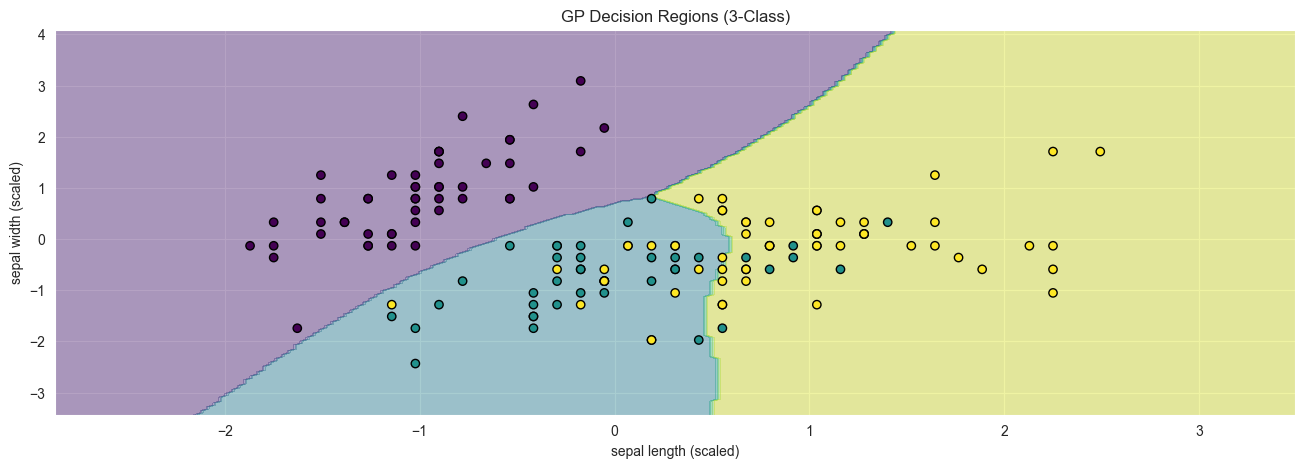

In [6]:
# -------------------------------------------------
# Build prediction grid
# -------------------------------------------------
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# GP probability predictions
probs = gp.predict_proba(grid)
probs_reshaped = probs.reshape(xx.shape + (3,))

# -------------------------------------------------
# Plot 1 — Decision boundaries
# -------------------------------------------------
plt.figure(figsize=(16,5))
Z = np.argmax(probs_reshaped, axis=2)
plt.contourf(xx, yy, Z, cmap="viridis", alpha=0.4)
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis", edgecolor="k")
plt.title("GP Decision Regions (3-Class)")
plt.xlabel("sepal length (scaled)")
plt.ylabel("sepal width (scaled)")


**Task 1g**: Create three plots with a heatmap highlighting the probability of each flower belonging to one of three classes.

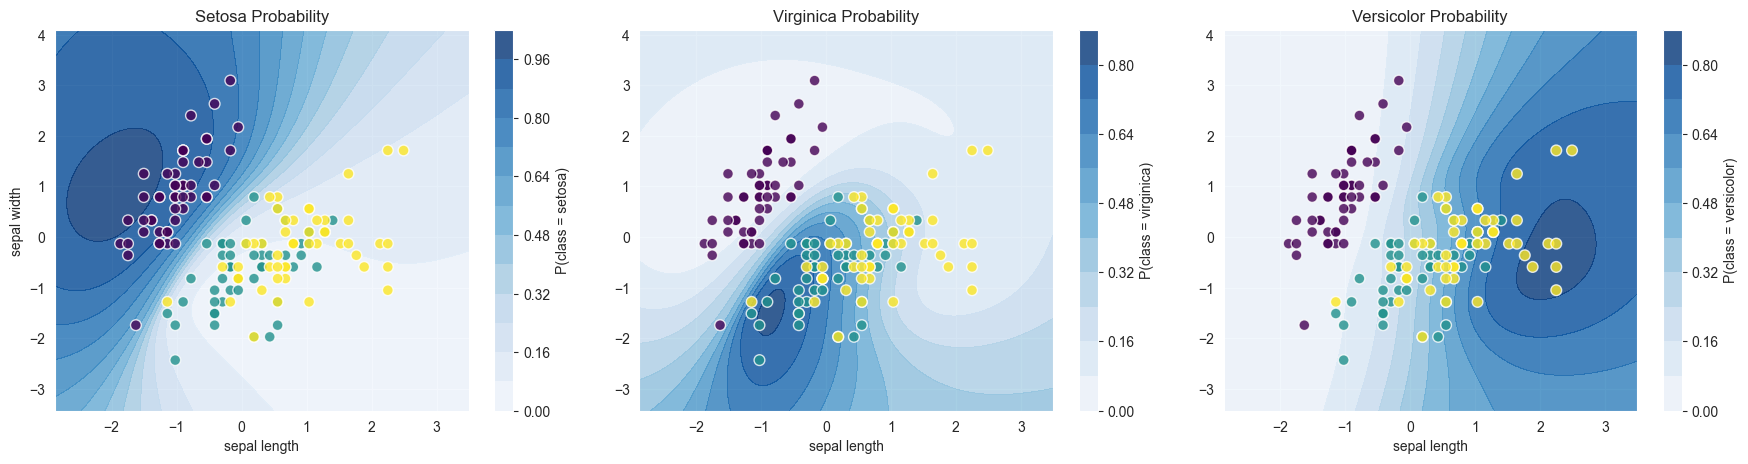

In [7]:
plt.figure(figsize=(18, 5))   # MORE SPACE

# Common scatter style
scatter_kwargs = dict(c=y, cmap="viridis", edgecolor="white", s=60, alpha=0.8)

# Clean contour style
contour_kwargs = dict(levels=12, cmap="Blues", alpha=0.8)

# -------------------------------------------------
# Plot 1 — Setosa
# -------------------------------------------------
plt.subplot(1, 3, 1)
plt.contourf(xx, yy, probs_reshaped[:, :, 0], **contour_kwargs)
plt.colorbar(label="P(class = setosa)")
plt.scatter(X[:,0], X[:,1], **scatter_kwargs)
plt.title("Setosa Probability")

plt.xlabel("sepal length")
plt.ylabel("sepal width")

# -------------------------------------------------
# Plot 2 — Virginica
# -------------------------------------------------
plt.subplot(1, 3, 2)
plt.contourf(xx, yy, probs_reshaped[:, :, 1], **contour_kwargs)
plt.colorbar(label="P(class = virginica)")
plt.scatter(X[:,0], X[:,1], **scatter_kwargs)
plt.title("Virginica Probability")

plt.xlabel("sepal length")
plt.ylabel("")   # remove label

# -------------------------------------------------
# Plot 3 — Versicolor
# -------------------------------------------------
plt.subplot(1, 3, 3)
plt.contourf(xx, yy, probs_reshaped[:, :, 2], **contour_kwargs)
plt.colorbar(label="P(class = versicolor)")
plt.scatter(X[:,0], X[:,1], **scatter_kwargs)
plt.title("Versicolor Probability")

plt.xlabel("sepal length")
plt.ylabel("")   # remove label

# Add space between plots
plt.tight_layout(pad=2.0)

plt.show()
